In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load data
lsoas = pd.read_csv('data/test_lsoas.csv')
imd_full = pd.read_csv('data/govuk2.csv')

# Extract sub-domain score columns
score_cols = [c for c in imd_full.columns if 'Score' in c]
lsoa_col = imd_full.columns[0]
imd_features = imd_full[[lsoa_col] + score_cols].copy()
imd_features.columns = ['LSOA11CD'] + [f'score_{i}' for i in range(len(score_cols))]
lsoas_merged = lsoas.merge(imd_features, on='LSOA11CD', how='inner')
score_feature_cols = [c for c in lsoas_merged.columns if c.startswith('score_')]

print(f'LSOAs loaded: {len(lsoas_merged)}')
print(f'Sub-domain score columns: {len(score_feature_cols)}')

Device: cpu
LSOAs loaded: 2000
Sub-domain score columns: 16


In [2]:
# ── Add borough information for spatial CV ────────────────────────────────────
# Extract borough from LSOA name — first two letters of LSOA code identify the LAD
# Use the LAD code from the boundaries file if available, otherwise derive from LSOA code
# London LSOAs: E01XXXXXX where borough is encoded in digits 3-5
# Simpler: group by first 6 characters of LSOA code (proxy for borough)

# Load full LSOA-to-borough mapping from IMD file
borough_col = [c for c in imd_full.columns if 'District' in c or 'Authority' in c or 'LAD' in c]
print('Potential borough columns:', borough_col)

if borough_col:
    borough_map = imd_full[[lsoa_col, borough_col[0]]].copy()
    borough_map.columns = ['LSOA11CD', 'borough']
    lsoas_merged = lsoas_merged.merge(borough_map, on='LSOA11CD', how='left')
    print(f'Boroughs found: {lsoas_merged["borough"].nunique()}')
    print(lsoas_merged['borough'].value_counts().head(10))
else:
    # Fallback: derive borough proxy from LSOA code digits
    lsoas_merged['borough'] = lsoas_merged['LSOA11CD'].str[3:6]
    print(f'Borough proxies (from LSOA code): {lsoas_merged["borough"].nunique()}')

Potential borough columns: ['Local Authority District code (2019)', 'Local Authority District name (2019)']
Boroughs found: 54
borough
E09000006    114
E09000003     90
E09000008     76
E09000011     73
E09000026     66
E09000007     65
E09000023     64
E09000010     62
E09000025     61
E09000005     59
Name: count, dtype: int64


In [3]:
# ── Extract embeddings (per image, not per LSOA) ──────────────────────────────
class ImageListDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.paths[idx]).convert('RGB'))

def extract_embeddings(model, paths, transform, batch_size=32, desc=''):
    loader = DataLoader(ImageListDataset(paths, transform),
                        batch_size=batch_size, shuffle=False, num_workers=0)
    all_embs = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            emb = model(batch.to(device)).squeeze(-1).squeeze(-1)
            all_embs.append(emb.cpu().numpy())
            if (i+1) % 20 == 0:
                print(f'  {desc}: {min((i+1)*batch_size, len(paths))}/{len(paths)}')
    return np.vstack(all_embs)

transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Load backbones
print('Loading ResNet-50...')
resnet = models.resnet50(weights='IMAGENET1K_V2')
sv_backbone = nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()
for p in sv_backbone.parameters(): p.requires_grad = False

print('Loading EfficientNet-B2...')
effnet = models.efficientnet_b2(weights='IMAGENET1K_V1')
aerial_backbone = nn.Sequential(effnet.features, effnet.avgpool).to(device).eval()
for p in aerial_backbone.parameters(): p.requires_grad = False

print('Backbones ready')

Loading ResNet-50...
Loading EfficientNet-B2...
Backbones ready


In [4]:
# ── Build image records (keep track of which LSOA each image belongs to) ──────
street_dir = 'data/images/'
aerial_dir = 'data/aerial_images/'
valid_lsoas = set(lsoas_merged['LSOA11CD'].values)

sv_records = []
for fname in os.listdir(street_dir):
    if not fname.endswith('.jpg') or fname == 'test_image.jpg': continue
    lsoa_code = fname.rsplit('_', 1)[0]
    if lsoa_code in valid_lsoas:
        sv_records.append({'path': os.path.join(street_dir, fname), 'lsoa': lsoa_code})
sv_df = pd.DataFrame(sv_records)

aerial_records = []
for fname in os.listdir(aerial_dir):
    if not fname.endswith('.jpg') or fname == 'test_aerial.jpg': continue
    lsoa_code = fname.replace('.jpg', '')
    if lsoa_code in valid_lsoas:
        aerial_records.append({'path': os.path.join(aerial_dir, fname), 'lsoa': lsoa_code})
aerial_df = pd.DataFrame(aerial_records)

print(f'Street view images: {len(sv_df)}')
print(f'Aerial images: {len(aerial_df)}')

# Extract embeddings
print('\nExtracting street view embeddings...')
sv_embs = extract_embeddings(sv_backbone, sv_df['path'].tolist(), transform, desc='SV')
sv_df['emb_idx'] = range(len(sv_df))

print('\nExtracting aerial embeddings...')
aerial_embs = extract_embeddings(aerial_backbone, aerial_df['path'].tolist(), transform, desc='Aerial')
aerial_df['emb_idx'] = range(len(aerial_df))

print('Done extracting embeddings')

Street view images: 6924
Aerial images: 2000

Extracting street view embeddings...
  SV: 640/6924
  SV: 1280/6924
  SV: 1920/6924
  SV: 2560/6924
  SV: 3200/6924
  SV: 3840/6924
  SV: 4480/6924
  SV: 5120/6924
  SV: 5760/6924
  SV: 6400/6924

Extracting aerial embeddings...
  Aerial: 640/2000
  Aerial: 1280/2000
  Aerial: 1920/2000
Done extracting embeddings


In [5]:
# ── Build LSOA-level feature matrix ───────────────────────────────────────────
# Street view: mean-pool all image embeddings per LSOA before regression
# (embedding averaging — more stable than prediction averaging for frozen features)

common_lsoas = sorted(
    set(sv_df['lsoa'].unique()) &
    set(aerial_df['lsoa'].unique()) &
    valid_lsoas
)
print(f'LSOAs with both modalities: {len(common_lsoas)}')

# Mean-pool aerial (one image per LSOA anyway)
aerial_lsoa_embs = {}
for lsoa, grp in aerial_df.groupby('lsoa'):
    aerial_lsoa_embs[lsoa] = aerial_embs[grp['emb_idx'].values].mean(axis=0)

# For street view: store ALL individual image embeddings per LSOA
sv_lsoa_embs_all = {}  # lsoa -> list of embeddings
for lsoa, grp in sv_df.groupby('lsoa'):
    sv_lsoa_embs_all[lsoa] = sv_embs[grp['emb_idx'].values]  # (n_imgs, 2048)

# Build LSOA-level arrays
# Use embedding average for the main feature matrix
# (prediction averaging is done during CV below)
X_sv_avg  = np.array([sv_lsoa_embs_all[l].mean(axis=0) for l in common_lsoas])   # (N, 2048)
X_aerial  = np.array([aerial_lsoa_embs[l] for l in common_lsoas])                # (N, 1408)
X_img     = np.hstack([X_sv_avg, X_aerial])                                       # (N, 3456)
X_tab     = np.array([lsoas_merged[lsoas_merged['LSOA11CD']==l][score_feature_cols].values[0].astype(float)
                      for l in common_lsoas])
y         = np.array([float(lsoas_merged[lsoas_merged['LSOA11CD']==l]['IMD19'].values[0])
                      for l in common_lsoas])
boroughs  = np.array([lsoas_merged[lsoas_merged['LSOA11CD']==l]['borough'].values[0]
                      for l in common_lsoas])

print(f'Feature matrix: {X_img.shape}')
print(f'Tabular: {X_tab.shape}')
print(f'Unique boroughs: {len(np.unique(boroughs))}')

LSOAs with both modalities: 1731
Feature matrix: (1731, 3456)
Tabular: (1731, 16)
Unique boroughs: 51


In [6]:
# ── Spatial Cross-Validation ──────────────────────────────────────────────────
# Hold out entire boroughs as test set — forces model to generalise to new areas

unique_boroughs = np.unique(boroughs)
n_boroughs = len(unique_boroughs)
print(f'Total boroughs: {n_boroughs}')

# Group boroughs into 5 spatial folds
np.random.seed(42)
shuffled_boroughs = np.random.permutation(unique_boroughs)
borough_folds = np.array_split(shuffled_boroughs, 5)

oof_img   = np.zeros(len(y))
oof_tab   = np.zeros(len(y))
oof_fused = np.zeros(len(y))

fold_r2_img, fold_r2_tab, fold_r2_fused = [], [], []
best_pca_dims = []

for fold, test_boroughs in enumerate(borough_folds):
    val_mask   = np.isin(boroughs, test_boroughs)
    train_mask = ~val_mask

    Xi_tr, Xi_val = X_img[train_mask], X_img[val_mask]
    Xt_tr, Xt_val = X_tab[train_mask], X_tab[val_mask]
    y_tr,  y_val  = y[train_mask],     y[val_mask]

    y_mean, y_std = y_tr.mean(), y_tr.std()
    y_tr_n = (y_tr - y_mean) / y_std

    # Standardise image features
    img_scaler = StandardScaler()
    Xi_tr_s = img_scaler.fit_transform(Xi_tr)
    Xi_val_s = img_scaler.transform(Xi_val)

    # PCA dimension search (train only)
    best_pca_r2 = -999
    best_n = 50
    for n_pca in [20, 50, 100]:
        pca_try = PCA(n_components=min(n_pca, Xi_tr_s.shape[1], Xi_tr_s.shape[0]-1), random_state=42)
        Xp_tr = pca_try.fit_transform(Xi_tr_s)
        Xp_val = pca_try.transform(Xi_val_s)
        r_try = RidgeCV(alphas=np.logspace(-2, 4, 30), cv=3).fit(Xp_tr, y_tr_n)
        r2_try = r2_score(y_val, r_try.predict(Xp_val) * y_std + y_mean)
        if r2_try > best_pca_r2:
            best_pca_r2 = r2_try
            best_n = n_pca
    best_pca_dims.append(best_n)

    # Final PCA with best n
    pca = PCA(n_components=min(best_n, Xi_tr_s.shape[1], Xi_tr_s.shape[0]-1), random_state=42)
    Xi_tr_pca = pca.fit_transform(Xi_tr_s)
    Xi_val_pca = pca.transform(Xi_val_s)

    # Standardise tabular
    tab_scaler = StandardScaler()
    Xt_tr_s = tab_scaler.fit_transform(Xt_tr)
    Xt_val_s = tab_scaler.transform(Xt_val)

    alphas = np.logspace(-2, 4, 50)

    # 1. Images only
    r_img = RidgeCV(alphas=alphas, cv=5).fit(Xi_tr_pca, y_tr_n)
    p_img = r_img.predict(Xi_val_pca) * y_std + y_mean

    # 2. Tabular only
    r_tab = RidgeCV(alphas=alphas, cv=5).fit(Xt_tr_s, y_tr_n)
    p_tab = r_tab.predict(Xt_val_s) * y_std + y_mean

    # 3. Fused
    X_fused_tr  = np.hstack([Xi_tr_pca, Xt_tr_s])
    X_fused_val = np.hstack([Xi_val_pca, Xt_val_s])
    r_fused = RidgeCV(alphas=alphas, cv=5).fit(X_fused_tr, y_tr_n)
    p_fused = r_fused.predict(X_fused_val) * y_std + y_mean

    oof_img[val_mask]   = p_img
    oof_tab[val_mask]   = p_tab
    oof_fused[val_mask] = p_fused

    r2_i = r2_score(y_val, p_img)
    r2_t = r2_score(y_val, p_tab)
    r2_f = r2_score(y_val, p_fused)
    fold_r2_img.append(r2_i)
    fold_r2_tab.append(r2_t)
    fold_r2_fused.append(r2_f)

    print(f'Fold {fold+1} | Img: {r2_i:.4f} | Tab: {r2_t:.4f} | Fused: {r2_f:.4f} | Best PCA: {best_n} | Test boroughs: {len(test_boroughs)}')

print()
print(f'=== Spatial CV OOF R² Images only  : {r2_score(y, oof_img):.4f} ===')
print(f'=== Spatial CV OOF R² Tabular only : {r2_score(y, oof_tab):.4f} ===')
print(f'=== Spatial CV OOF R² Fused        : {r2_score(y, oof_fused):.4f} ===')
print(f'Best PCA dims per fold: {best_pca_dims}')

Total boroughs: 51
Fold 1 | Img: 0.3142 | Tab: 0.9756 | Fused: 0.9757 | Best PCA: 100 | Test boroughs: 11
Fold 2 | Img: 0.1975 | Tab: 0.9795 | Fused: 0.9789 | Best PCA: 100 | Test boroughs: 10
Fold 3 | Img: 0.2062 | Tab: 0.9756 | Fused: 0.9747 | Best PCA: 100 | Test boroughs: 10
Fold 4 | Img: 0.3353 | Tab: 0.9740 | Fused: 0.9739 | Best PCA: 100 | Test boroughs: 10
Fold 5 | Img: 0.2450 | Tab: 0.9749 | Fused: 0.9742 | Best PCA: 100 | Test boroughs: 10

=== Spatial CV OOF R² Images only  : 0.2682 ===
=== Spatial CV OOF R² Tabular only : 0.9759 ===
=== Spatial CV OOF R² Fused        : 0.9755 ===
Best PCA dims per fold: [100, 100, 100, 100, 100]


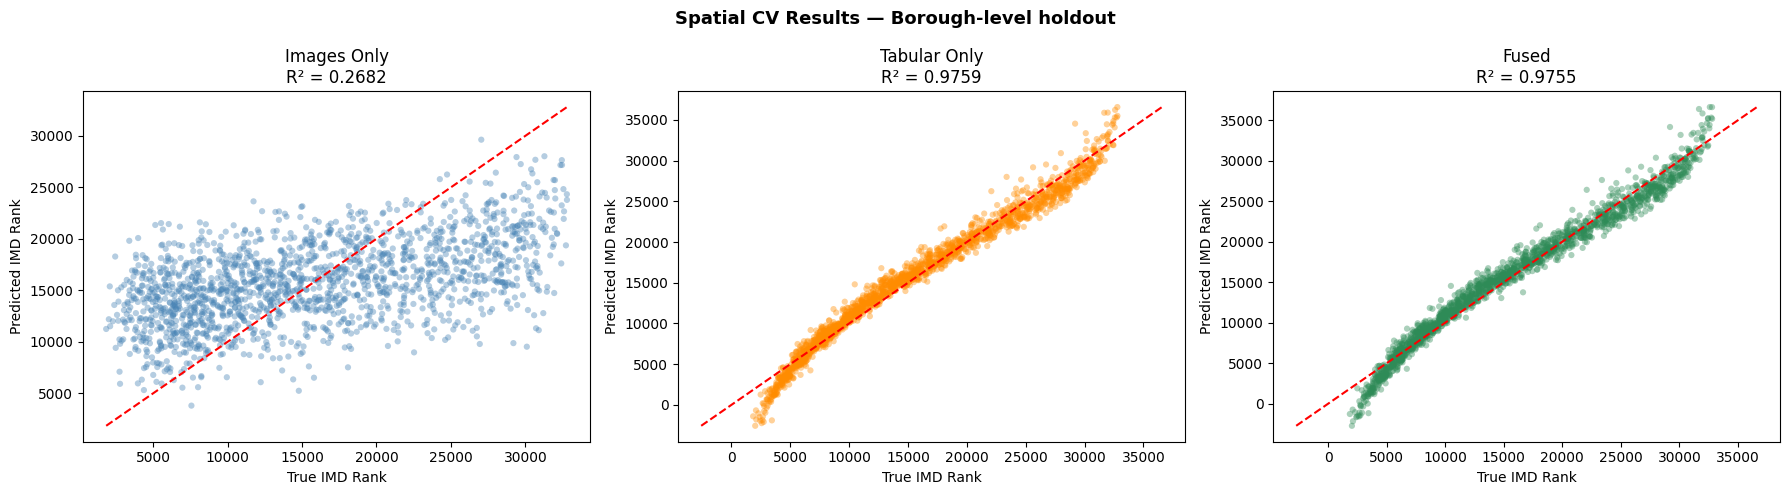

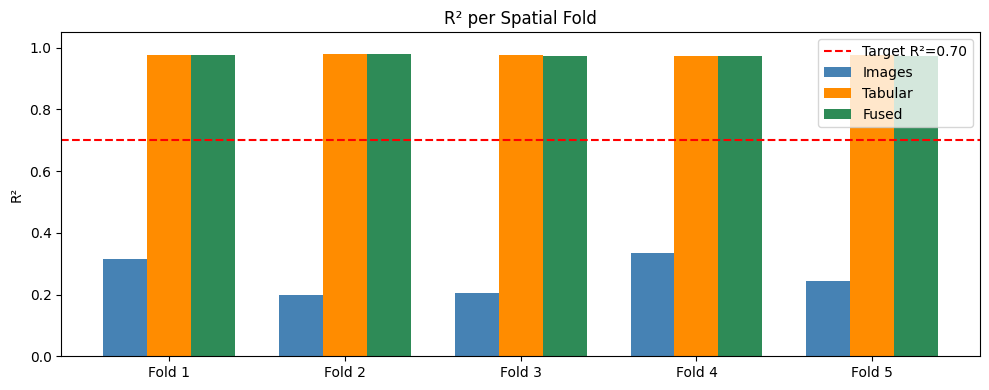

In [7]:
# ── Plots ─────────────────────────────────────────────────────────────────────
os.makedirs('outputs', exist_ok=True)

r2_img_final   = r2_score(y, oof_img)
r2_tab_final   = r2_score(y, oof_tab)
r2_fused_final = r2_score(y, oof_fused)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, title, r2, col in zip(
    axes,
    [oof_img, oof_tab, oof_fused],
    ['Images Only', 'Tabular Only', 'Fused'],
    [r2_img_final, r2_tab_final, r2_fused_final],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.scatter(y, preds, alpha=0.4, s=20, color=col, edgecolors='none')
    lims = [min(y.min(), preds.min()), max(y.max(), preds.max())]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_title(f'{title}\nR² = {r2:.4f}', fontsize=12)
    ax.set_xlabel('True IMD Rank')
    ax.set_ylabel('Predicted IMD Rank')

plt.suptitle('Spatial CV Results — Borough-level holdout', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/spatial_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Fold comparison
fig2, ax2 = plt.subplots(figsize=(10, 4))
x = np.arange(5)
w = 0.25
ax2.bar(x - w, fold_r2_img,   w, label='Images', color='steelblue')
ax2.bar(x,     fold_r2_tab,   w, label='Tabular', color='darkorange')
ax2.bar(x + w, fold_r2_fused, w, label='Fused', color='seagreen')
ax2.axhline(0.7, color='red', linestyle='--', lw=1.5, label='Target R²=0.70')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax2.set_ylabel('R²')
ax2.set_title('R² per Spatial Fold')
ax2.legend()
ax2.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('outputs/spatial_cv_folds.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Save final model ──────────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

best_n_final = int(np.median(best_pca_dims))
print(f'Using PCA n_components = {best_n_final} for final model')

img_scaler_f = StandardScaler()
Xi_all_s = img_scaler_f.fit_transform(X_img)
pca_f = PCA(n_components=best_n_final, random_state=42)
Xi_all_pca = pca_f.fit_transform(Xi_all_s)

tab_scaler_f = StandardScaler()
Xt_all_s = tab_scaler_f.fit_transform(X_tab)

X_fused_all = np.hstack([Xi_all_pca, Xt_all_s])
y_mean_f, y_std_f = y.mean(), y.std()
y_norm_f = (y - y_mean_f) / y_std_f

ridge_f = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5)
ridge_f.fit(X_fused_all, y_norm_f)

with open('models/final_spatial_bundle.pkl', 'wb') as f:
    pickle.dump({
        'img_scaler': img_scaler_f, 'pca': pca_f,
        'tab_scaler': tab_scaler_f, 'ridge': ridge_f,
        'y_mean': y_mean_f, 'y_std': y_std_f,
        'score_cols': score_feature_cols
    }, f)

print('Saved to models/final_spatial_bundle.pkl')
print(f'Final alpha: {ridge_f.alpha_:.4f}')
print(f'\nFinal Results Summary:')
print(f'  Images only  (spatial CV): {r2_img_final:.4f}')
print(f'  Tabular only (spatial CV): {r2_tab_final:.4f}')
print(f'  Fused        (spatial CV): {r2_fused_final:.4f}')

Using PCA n_components = 100 for final model
Saved to models/final_spatial_bundle.pkl
Final alpha: 0.0100

Final Results Summary:
  Images only  (spatial CV): 0.2682
  Tabular only (spatial CV): 0.9759
  Fused        (spatial CV): 0.9755
